# 03 — TFT Forecaster
### Standard Temporal Fusion Transformer — Event-Based Breakdown Forecasting
> Run 00_Data_Preparation.ipynb first.
>
> **Model A:** Binary forecaster (breakdown coming within H=5 events?)
> **Model B:** Type forecaster (which breakdown type is coming?)


In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cpu


In [2]:
with open('prepared_forecasting.pkl','rb') as f: d = pickle.load(f)
with open('encoder_reason.pkl','rb') as f: encoder_reason = pickle.load(f)

X_train      = torch.FloatTensor(d['X_fc_train_seq']).to(DEVICE)
X_test       = torch.FloatTensor(d['X_fc_test_seq']).to(DEVICE)
y_train_bin  = torch.LongTensor(d['y_fc_train_bin_seq']).to(DEVICE)
y_test_bin   = torch.LongTensor(d['y_fc_test_bin_seq']).to(DEVICE)
y_train_type = torch.LongTensor(d['y_fc_train_type_seq']).to(DEVICE)
y_test_type  = torch.LongTensor(d['y_fc_test_type_seq']).to(DEVICE)

NUM_FEATURES       = d['num_features']
TIME_STEPS         = d['TIME_STEPS']
H                  = d['H']
NUM_REASON_CLASSES = d['num_reason_classes']

# CLASS WEIGHTS (binary)
cc_bin      = np.bincount(d['y_fc_train_bin_seq'])
cw_bin      = 1.0 / cc_bin
cw_bin      = cw_bin / cw_bin.sum() * len(cw_bin)
weights_bin = torch.FloatTensor(cw_bin).to(DEVICE)

train_loader_bin = DataLoader(TensorDataset(X_train, y_train_bin), batch_size=16, shuffle=True)

print(f'✅ Data loaded.')
print(f'   Features: {NUM_FEATURES}, TIME_STEPS: {TIME_STEPS}, H: {H}')
print(f'   Binary class counts  : {cc_bin}')
print(f'   Binary class weights : {cw_bin.round(3)}')
print(f'   Reason classes       : {list(encoder_reason.classes_)}')


✅ Data loaded.
   Features: 67, TIME_STEPS: 5, H: 5
   Binary class counts  : [14730    65]
   Binary class weights : [0.009 1.991]
   Reason classes       : ['High Thread Tension', 'No Breakdown']


---
## TFT Architecture
> hidden_size=16, num_heads=1, 1 LSTM layer, dropout=0.4


In [3]:
class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1        = nn.Linear(input_size, hidden_size)
        self.fc2        = nn.Linear(hidden_size, output_size)
        self.gate_fc    = nn.Linear(hidden_size, output_size)
        self.elu        = nn.ELU()
        self.sigmoid    = nn.Sigmoid()
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual   = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h    = self.elu(self.fc1(x))
        h    = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


class TFT_Forecaster(nn.Module):
    def __init__(self, num_features, time_steps, num_classes,
                 hidden_size=16, num_heads=1, dropout=0.4):
        super().__init__()
        self.time_steps    = time_steps
        self.input_proj    = GRN(num_features, hidden_size, hidden_size, dropout)
        # 1 LSTM layer — simplest possible sequential encoder
        self.lstm_encoder  = nn.LSTM(hidden_size, hidden_size, 1, batch_first=True)
        self.attention     = nn.MultiheadAttention(hidden_size, num_heads,
                                                    dropout=dropout, batch_first=True)
        self.attn_norm     = nn.LayerNorm(hidden_size)
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        proj_out = [self.input_proj(x[:, t, :]) for t in range(self.time_steps)]
        proj_seq = torch.stack(proj_out, dim=1)
        lstm_out, _ = self.lstm_encoder(proj_seq)
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(attn_out + lstm_out)
        out = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)


---
## Model A — Binary Forecaster
> Predicts: will a breakdown happen within the next 5 events?


In [4]:
model_a = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=2, hidden_size=16, num_heads=1, dropout=0.4
).to(DEVICE)
print(f'TFT Model A (Binary) parameters: {sum(p.numel() for p in model_a.parameters()):,}')


TFT Model A (Binary) parameters: 7,202


Training TFT Model A (Binary Forecaster)...
Epoch   1 | Train: 0.0308 | Val: 0.0283
Epoch   2 | Train: 0.0302 | Val: 0.0284
Epoch   3 | Train: 0.0281 | Val: 0.0304
Epoch   4 | Train: 0.0284 | Val: 0.0289
Epoch   5 | Train: 0.0280 | Val: 0.0280
Epoch   6 | Train: 0.0284 | Val: 0.0283
Epoch   7 | Train: 0.0275 | Val: 0.0289
Epoch   8 | Train: 0.0261 | Val: 0.0321
Epoch   9 | Train: 0.0265 | Val: 0.0305
Epoch  10 | Train: 0.0260 | Val: 0.0311
Epoch  11 | Train: 0.0250 | Val: 0.0293
Epoch  12 | Train: 0.0232 | Val: 0.0311
Epoch  13 | Train: 0.0237 | Val: 0.0307
Epoch  14 | Train: 0.0237 | Val: 0.0345
Epoch  15 | Train: 0.0222 | Val: 0.0375
Epoch  16 | Train: 0.0226 | Val: 0.0359
Epoch  17 | Train: 0.0209 | Val: 0.0369
Epoch  18 | Train: 0.0204 | Val: 0.0358
Epoch  19 | Train: 0.0192 | Val: 0.0386
Early stopping at epoch 20

✅ Best val loss: 0.0280 — best checkpoint restored.


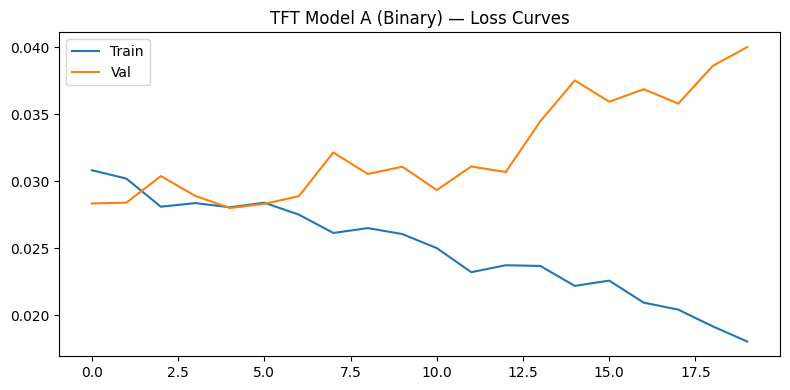

In [ ]:
EPOCHS    = 100
optimizer = torch.optim.Adam(model_a.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 15
train_losses, val_losses = [], []

print('Training TFT Model A (Binary Forecaster)...')
for epoch in range(EPOCHS):
    model_a.train()
    batch_losses = []
    for xb, yb in train_loader_bin:
        optimizer.zero_grad()
        loss = criterion(model_a(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_a.parameters(), 0.5)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    model_a.eval()
    with torch.no_grad():
        val_loss = criterion(model_a(X_test), y_test_bin).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_a.state_dict(), 'best_tft_binary.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

model_a.load_state_dict(torch.load('best_tft_binary.pt'))
print(f'\n✅ Best val loss: {best_val_loss:.4f} — best checkpoint restored.')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('TFT Model A (Binary) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_binary_loss.png', dpi=150); plt.show()


#### Evaluate Model A


TFT MODEL A — BINARY FORECASTER RESULTS
Accuracy : 99.57%
F1 Score : 0.9935
RMSE     : 0.0658
MAE      : 0.0043

                  precision    recall  f1-score   support

            Safe       1.00      1.00      1.00      3679
Breakdown Coming       0.00      0.00      0.00        16

        accuracy                           1.00      3695
       macro avg       0.50      0.50      0.50      3695
    weighted avg       0.99      1.00      0.99      3695



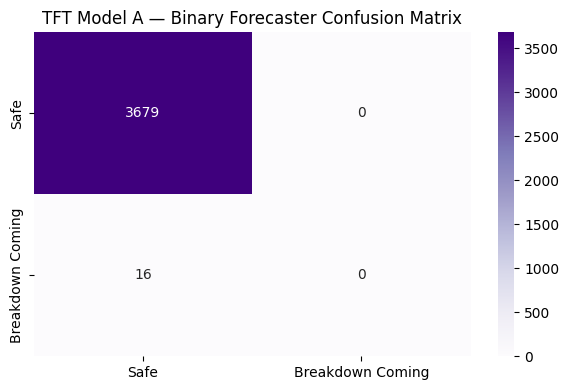

✅ Model A results saved.


In [6]:
model_a.eval()
with torch.no_grad():
    y_pred_bin = np.argmax(torch.softmax(model_a(X_test), dim=1).cpu().numpy(), axis=1)
    y_true_bin = y_test_bin.cpu().numpy()

acc  = accuracy_score(y_true_bin, y_pred_bin)
f1   = f1_score(y_true_bin, y_pred_bin, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true_bin, y_pred_bin))
mae  = mean_absolute_error(y_true_bin, y_pred_bin)

print('='*50)
print('TFT MODEL A — BINARY FORECASTER RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true_bin, y_pred_bin, target_names=['Safe','Breakdown Coming']))

cm = confusion_matrix(y_true_bin, y_pred_bin)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Safe','Breakdown Coming'],
            yticklabels=['Safe','Breakdown Coming'])
plt.title('TFT Model A — Binary Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_binary_confusion.png', dpi=150); plt.show()

tft_binary_results = {'model':'TFT Forecaster','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('tft_binary_results.pkl','wb') as f: pickle.dump(tft_binary_results, f)
print('✅ Model A results saved.')


---
## Model B — Type Forecaster
> Trained only on records where breakdown IS coming.
> Predicts which breakdown type is approaching.


In [7]:
# Filter: only sequences where breakdown IS coming
mask_train = d['y_fc_train_bin_seq'] == 1
mask_test  = d['y_fc_test_bin_seq'] == 1

X_tr_type = torch.FloatTensor(d['X_fc_train_seq'][mask_train]).to(DEVICE)
X_te_type = torch.FloatTensor(d['X_fc_test_seq'][mask_test]).to(DEVICE)
y_tr_type = torch.LongTensor(d['y_fc_train_type_seq'][mask_train]).to(DEVICE)
y_te_type = torch.LongTensor(d['y_fc_test_type_seq'][mask_test]).to(DEVICE)

unique_types_train = np.unique(d['y_fc_train_type_seq'][mask_train])
print(f'✅ Type forecaster data ready.')
print(f'   Train: {X_tr_type.shape}  Test: {X_te_type.shape}')
print(f'   Unique breakdown types in train: {unique_types_train}')

# Class weights — robust to single-class edge case
if len(unique_types_train) > 1:
    cc_type  = np.bincount(d['y_fc_train_type_seq'][mask_train])
    cw_type  = np.where(cc_type > 0, 1.0 / cc_type, 0.0)
    cw_type  = cw_type / cw_type[cw_type > 0].sum() * (cc_type > 0).sum()
    weights_type = torch.FloatTensor(cw_type).to(DEVICE)
    print(f'   Type class counts  : {cc_type}')
    print(f'   Type class weights : {cw_type.round(3)}')
else:
    weights_type = torch.ones(NUM_REASON_CLASSES, dtype=torch.float32).to(DEVICE)
    print('⚠️  Only one breakdown type in training data — using uniform weights.')

train_loader_type = DataLoader(TensorDataset(X_tr_type, y_tr_type), batch_size=16, shuffle=True)


✅ Type forecaster data ready.
   Train: torch.Size([65, 5, 67])  Test: torch.Size([16, 5, 67])
   Unique breakdown types in train: [0]
⚠️  Only one breakdown type in training data — using uniform weights.


TFT Model B (Type) parameters: 7,202
Training TFT Model B (Type Forecaster)...
Epoch   1 | Train: 0.4726 | Val: 0.4041
Epoch   2 | Train: 0.3798 | Val: 0.3093
Epoch   3 | Train: 0.2818 | Val: 0.2548
Epoch   4 | Train: 0.2300 | Val: 0.2086
Epoch   5 | Train: 0.1899 | Val: 0.1700
Epoch   6 | Train: 0.1827 | Val: 0.1383
Epoch   7 | Train: 0.1552 | Val: 0.1108
Epoch   8 | Train: 0.1713 | Val: 0.0881
Epoch   9 | Train: 0.1052 | Val: 0.0694
Epoch  10 | Train: 0.0792 | Val: 0.0535
Epoch  11 | Train: 0.0549 | Val: 0.0408
Epoch  12 | Train: 0.0547 | Val: 0.0315
Epoch  13 | Train: 0.0480 | Val: 0.0245
Epoch  14 | Train: 0.0431 | Val: 0.0192
Epoch  15 | Train: 0.0275 | Val: 0.0154
Epoch  16 | Train: 0.0296 | Val: 0.0126
Epoch  17 | Train: 0.0345 | Val: 0.0105
Epoch  18 | Train: 0.0193 | Val: 0.0089
Epoch  19 | Train: 0.0257 | Val: 0.0077
Epoch  20 | Train: 0.0140 | Val: 0.0068
Epoch  21 | Train: 0.0098 | Val: 0.0061
Epoch  22 | Train: 0.0132 | Val: 0.0056
Epoch  23 | Train: 0.0152 | Val: 0.0051
E

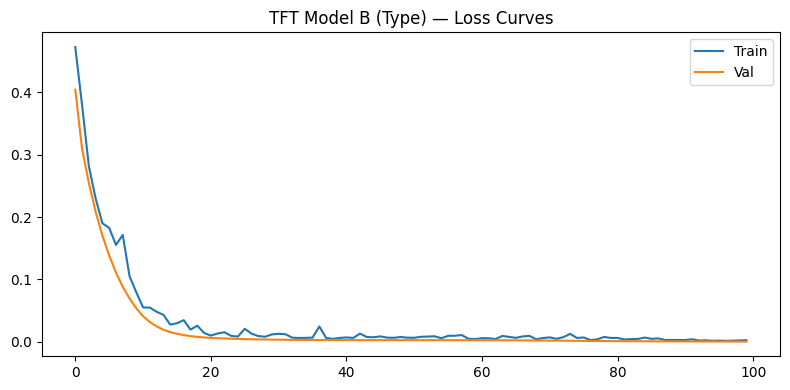

In [8]:
model_b = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=NUM_REASON_CLASSES, hidden_size=16, num_heads=1, dropout=0.4
).to(DEVICE)
print(f'TFT Model B (Type) parameters: {sum(p.numel() for p in model_b.parameters()):,}')

EPOCHS      = 100
optimizer_b = torch.optim.AdamW(model_b.parameters(), lr=1e-3, weight_decay=1e-2)
criterion_b = nn.CrossEntropyLoss(weight=weights_type)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=50)

best_val_loss_b = float('inf')
patience_b      = 0
PATIENCE_B      = 15
train_losses_b, val_losses_b = [], []

print('Training TFT Model B (Type Forecaster)...')
for epoch in range(EPOCHS):
    model_b.train()
    batch_losses = []
    for xb, yb in train_loader_type:
        optimizer_b.zero_grad()
        loss = criterion_b(model_b(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_b.parameters(), 0.5)
        optimizer_b.step()
        batch_losses.append(loss.item())
    scheduler_b.step()

    model_b.eval()
    with torch.no_grad():
        val_loss = criterion_b(model_b(X_te_type), y_te_type).item()
    train_loss = np.mean(batch_losses)
    train_losses_b.append(train_loss)
    val_losses_b.append(val_loss)

    if val_loss < best_val_loss_b:
        best_val_loss_b = val_loss
        torch.save(model_b.state_dict(), 'best_tft_type.pt')
        patience_b = 0
    else:
        patience_b += 1
        if patience_b >= PATIENCE_B:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

model_b.load_state_dict(torch.load('best_tft_type.pt'))
print(f'\n✅ Best val loss: {best_val_loss_b:.4f} — best checkpoint restored.')

plt.figure(figsize=(8,4))
plt.plot(train_losses_b, label='Train')
plt.plot(val_losses_b, label='Val')
plt.title('TFT Model B (Type) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_type_loss.png', dpi=150); plt.show()


#### Evaluate Model B


TFT MODEL B — TYPE FORECASTER RESULTS
Accuracy : 100.00%
F1 Score : 1.0000

                     precision    recall  f1-score   support

High Thread Tension       1.00      1.00      1.00        16

           accuracy                           1.00        16
          macro avg       1.00      1.00      1.00        16
       weighted avg       1.00      1.00      1.00        16



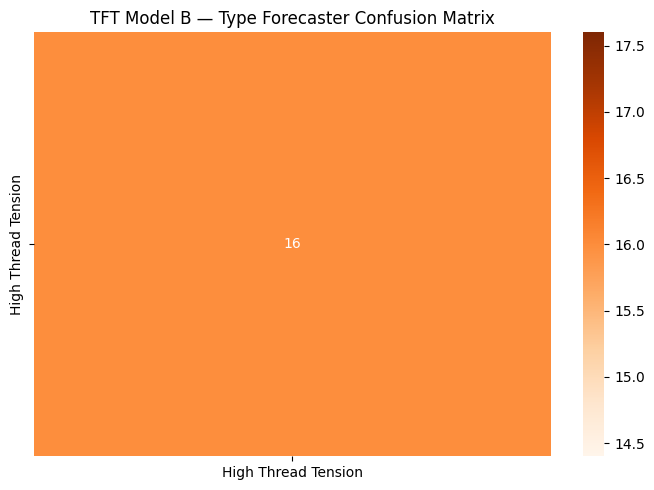

In [9]:
model_b.eval()
with torch.no_grad():
    y_pred_type = np.argmax(torch.softmax(model_b(X_te_type), dim=1).cpu().numpy(), axis=1)
    y_true_type = y_te_type.cpu().numpy()

unique_labels = sorted(set(y_true_type) | set(y_pred_type))
label_names   = [encoder_reason.classes_[i] for i in unique_labels]

print('='*50)
print('TFT MODEL B — TYPE FORECASTER RESULTS')
print('='*50)
print(f'Accuracy : {accuracy_score(y_true_type, y_pred_type)*100:.2f}%')
print(f'F1 Score : {f1_score(y_true_type, y_pred_type, average="weighted"):.4f}')
print()
print(classification_report(y_true_type, y_pred_type, labels=unique_labels, target_names=label_names))

cm = confusion_matrix(y_true_type, y_pred_type, labels=unique_labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names)
plt.title('TFT Model B — Type Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_type_confusion.png', dpi=150); plt.show()


#### Save Artifacts


In [10]:
tft_forecast_config = {
    'num_features'      : NUM_FEATURES,
    'time_steps'        : TIME_STEPS,
    'H'                 : H,
    'num_classes_binary': 2,
    'num_classes_type'  : NUM_REASON_CLASSES,
    'hidden_size'       : 16,
    'num_heads'         : 1,
}
with open('tft_forecast_config.pkl','wb') as f: pickle.dump(tft_forecast_config, f)
print('✅ Saved: best_tft_binary.pt | best_tft_type.pt | tft_forecast_config.pkl | tft_binary_results.pkl')


✅ Saved: best_tft_binary.pt | best_tft_type.pt | tft_forecast_config.pkl | tft_binary_results.pkl
